# Sentiment Analysis with Deep Learning (RNN, BiLSTM, GRU)

This notebook implements **RNN, BiLSTM, and BiGRU** models for sentiment classification using the Twitter dataset. We use **pre-trained GloVe embeddings** for word representation.

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional
from tensorflow.keras.optimizers import Adam, RMSprop
import os
import zipfile
import requests

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TestSolutions\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:

TRAIN_PATH = "../Datasets/twitter_training.csv"
VALID_PATH = "../Datasets/twitter_validation.csv"

cols = ["id", "entity", "sentiment", "text"]
train_df = pd.read_csv(TRAIN_PATH, header=None, names=cols)
valid_df = pd.read_csv(VALID_PATH, header=None, names=cols)

train_df["text"] = train_df["text"].fillna("")
valid_df["text"] = valid_df["text"].fillna("")

print(train_df.head())
print(train_df['sentiment'].value_counts())


     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


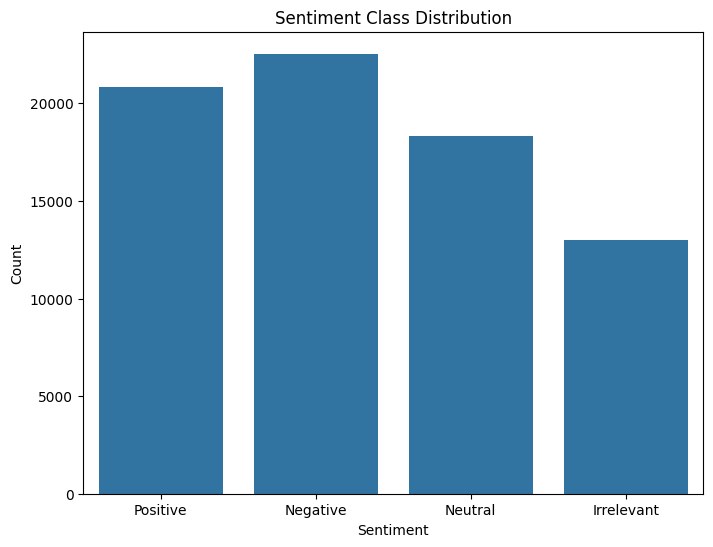

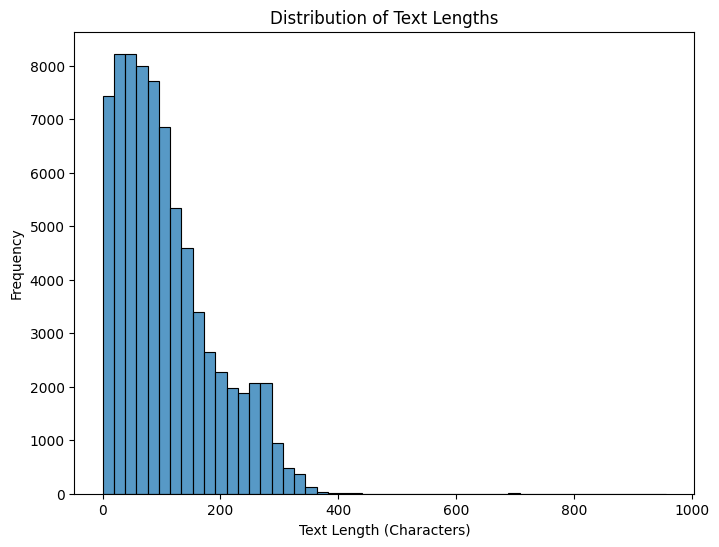

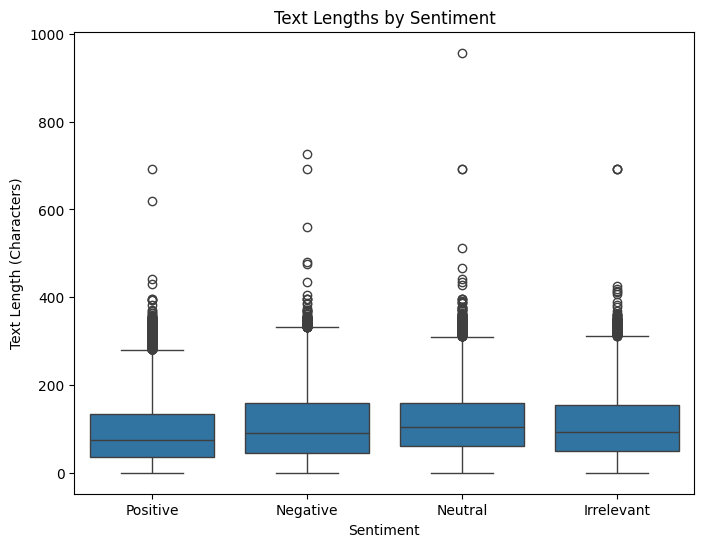

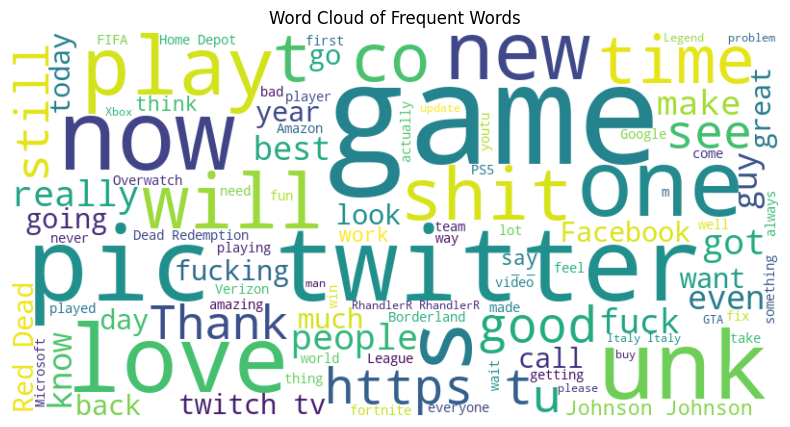

In [ ]:
# Cell 3: EDA Visualizations
# Create plots directory
os.makedirs("plots-twitter", exist_ok=True)

# Visualization 1: Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=train_df, order=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.savefig('plots-twitter/sentiment_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

# Visualization 2: Text Length Histogram
train_df['text_length'] = train_df['text'].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(train_df['text_length'], bins=50)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Frequency')
plt.savefig('plots-twitter/text_length_histogram.png', bbox_inches='tight', dpi=300)
plt.show()

# Visualization 3: Boxplot of Text Lengths by Sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(x='sentiment', y='text_length', data=train_df, order=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
plt.title('Text Lengths by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Text Length (Characters)')
plt.savefig('plots-twitter/text_length_by_sentiment.png', bbox_inches='tight', dpi=300)
plt.show()

# Visualization 4: Word Cloud for Frequent Words (Overall)
text_all = ' '.join(train_df['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text_all)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Frequent Words')
plt.savefig('plots-twitter/word_cloud.png', bbox_inches='tight', dpi=300)
plt.show()

In [4]:
# Cell 4: Preprocessing and GloVe Embeddings
import os
import zipfile
import requests
import numpy as np
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import re

# Check if glove.6B.100d.txt exists, download and extract if not
glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"
glove_dir = "glove"
glove_txt = os.path.join(glove_dir, "glove.twitter.27B.100d.txt")

# Ensure glove directory exists
os.makedirs(glove_dir, exist_ok=True)

if not os.path.exists(glove_txt):
    print(f"{glove_txt} not found. Attempting to download and extract GloVe 6B embeddings...")
    try:
        if not os.path.exists(glove_zip):
            print(f"Downloading {glove_zip} from {glove_url}...")
            response = requests.get(glove_url, stream=True)
            if response.status_code == 200:
                with open(glove_zip, 'wb') as f:
                    f.write(response.content)
                print(f"Downloaded {glove_zip} successfully.")
            else:
                raise Exception(f"Failed to download GloVe file. HTTP status code: {response.status_code}")
        
        print(f"Extracting {glove_zip} to {glove_dir}...")
        with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
            zip_ref.extractall(glove_dir)
        print(f"Extracted files to {glove_dir}.")
        
        # Verify the file exists after extraction
        if not os.path.exists(glove_txt):
            raise FileNotFoundError(f"Extraction completed, but {glove_txt} still not found in {glove_dir}.")
    except Exception as e:
        print(f"Error during download or extraction: {e}")
        raise
else:
    print(f"{glove_txt} found, skipping download.")

# Load GloVe embeddings (100d)
embeddings_index = {}
try:
    with open(glove_txt, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f"Loaded {len(embeddings_index)} word vectors from {glove_txt}.")
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find {glove_txt}. Please ensure the file is in the correct directory.")
except Exception as e:
    raise Exception(f"Error loading GloVe embeddings: {e}")

# Preprocessing function
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

train_df['text'] = train_df['text'].apply(preprocess_text)
valid_df['text'] = valid_df['text'].apply(preprocess_text)

# Tokenization
MAX_NUM_WORDS = 20000
MAX_SEQ_LEN = 100
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts(train_df['text'])
word_index = tokenizer.word_index

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['text']), maxlen=MAX_SEQ_LEN)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(valid_df['text']), maxlen=MAX_SEQ_LEN)

# Labels
le = LabelEncoder()
y_train = le.fit_transform(train_df['sentiment'])
y_val = le.transform(valid_df['sentiment'])
num_classes = len(le.classes_)
multiclass = num_classes > 2
y_train_keras = to_categorical(y_train, num_classes)
y_val_keras = to_categorical(y_val, num_classes)

# Class weights to handle imbalance
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

# Embedding matrix (adjusted for 100d)
vocab_size = min(MAX_NUM_WORDS, len(word_index) + 1)
embedding_matrix = np.zeros((vocab_size, 100))  # 100 dimensions for glove.6B.100d.txt
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

glove\glove.twitter.27B.100d.txt found, skipping download.
Loaded 1193514 word vectors from glove\glove.twitter.27B.100d.txt.


In [5]:
# Cell 5: Model Definitions
def build_rnn_model(vocab_size):
    model = Sequential()
    model.add(Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=MAX_SEQ_LEN, trainable=False))
    model.add(SimpleRNN(64, dropout=0.5, recurrent_dropout=0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

def build_bilstm_model(vocab_size):
    model = Sequential()
    model.add(Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=MAX_SEQ_LEN, trainable=False))
    model.add(Bidirectional(LSTM(64, dropout=0.5, recurrent_dropout=0.5)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

def build_gru_model(vocab_size):
    model = Sequential()
    model.add(Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=MAX_SEQ_LEN, trainable=False))
    model.add(Bidirectional(GRU(64, dropout=0.5, recurrent_dropout=0.5)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model


Running {'model_type': 'rnn', 'lr': 0.001, 'batch_size': 64, 'optimizer': 'adam', 'epochs': 10}


c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.2942 - loss: 1.4092 - val_accuracy: 0.4130 - val_loss: 1.3219
Epoch 2/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - accuracy: 0.3673 - loss: 1.3462 - val_accuracy: 0.4020 - val_loss: 1.3067
Epoch 3/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.3861 - loss: 1.3296 - val_accuracy: 0.4350 - val_loss: 1.2707
Epoch 4/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.3911 - loss: 1.3241 - val_accuracy: 0.4390 - val_loss: 1.2640
Epoch 5/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.3938 - loss: 1.3247 - val_accuracy: 0.4400 - val_loss: 1.2706
Epoch 6/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.3982 - loss: 1.3199 - val_accuracy: 0.4580 - val_loss: 1.2570
Epoch 7/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.3974 - loss: 1.3186 - val_accuracy: 0.4460 - val_loss: 1.2491
Epoch 8/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - accuracy: 0.3981 -

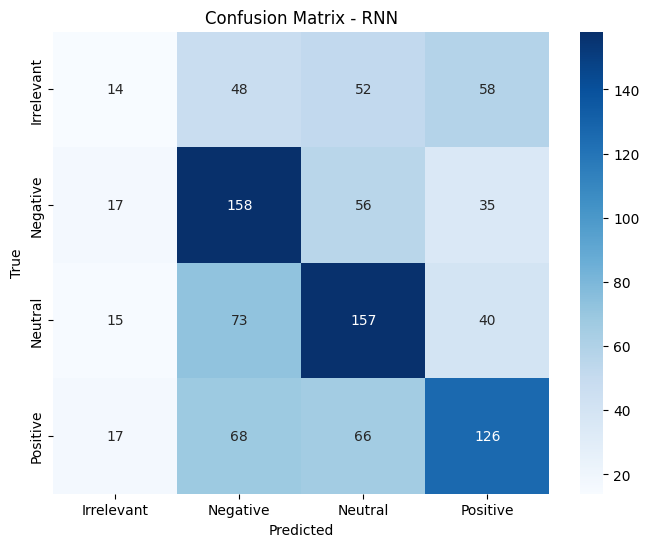


Running {'model_type': 'bilstm', 'lr': 0.001, 'batch_size': 64, 'optimizer': 'adam', 'epochs': 10}


c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 251s 203ms/step - accuracy: 0.4521 - loss: 1.2530 - val_accuracy: 0.5460 - val_loss: 1.0757
Epoch 2/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 240s 184ms/step - accuracy: 0.5010 - loss: 1.1781 - val_accuracy: 0.5890 - val_loss: 1.0181
Epoch 3/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 218s 187ms/step - accuracy: 0.5217 - loss: 1.1404 - val_accuracy: 0.6010 - val_loss: 0.9697
Epoch 4/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 226s 194ms/step - accuracy: 0.5320 - loss: 1.1179 - val_accuracy: 0.6190 - val_loss: 0.9391
Epoch 5/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 222s 190ms/step - accuracy: 0.5406 - loss: 1.0997 - val_accuracy: 0.6340 - val_loss: 0.8999
Epoch 6/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 209s 179ms/step - accuracy: 0.5471 - loss: 1.0834 - val_accuracy: 0.6440 - val_loss: 0.8704
Epoch 7/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 232s 199ms/step - accuracy: 0.5548 - loss: 1.0693 - val_accuracy: 0.6500 - val_loss: 0.8577
Epoch 8/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 239s 205ms/step - ac

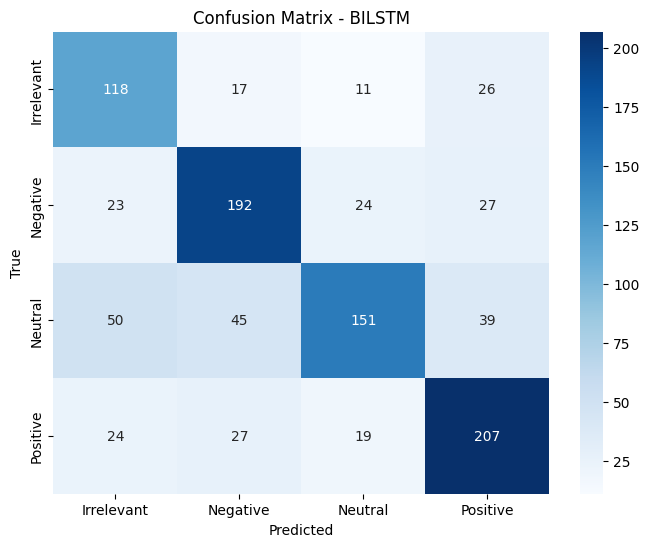


Running {'model_type': 'gru', 'lr': 0.001, 'batch_size': 64, 'optimizer': 'rmsprop', 'epochs': 10}
Epoch 1/10


c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1167/1167 ━━━━━━━━━━━━━━━━━━━━ 181s 147ms/step - accuracy: 0.4273 - loss: 1.2836 - val_accuracy: 0.5490 - val_loss: 1.1023
Epoch 2/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 155s 133ms/step - accuracy: 0.4874 - loss: 1.2006 - val_accuracy: 0.5700 - val_loss: 1.0466
Epoch 3/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 163s 139ms/step - accuracy: 0.5074 - loss: 1.1627 - val_accuracy: 0.5980 - val_loss: 1.0103
Epoch 4/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 192s 164ms/step - accuracy: 0.5190 - loss: 1.1376 - val_accuracy: 0.6020 - val_loss: 0.9683
Epoch 5/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 192s 165ms/step - accuracy: 0.5260 - loss: 1.1219 - val_accuracy: 0.6100 - val_loss: 0.9278
Epoch 6/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 189s 162ms/step - accuracy: 0.5290 - loss: 1.1099 - val_accuracy: 0.6240 - val_loss: 0.9343
Epoch 7/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 192s 165ms/step - accuracy: 0.5366 - loss: 1.1017 - val_accuracy: 0.6340 - val_loss: 0.9016
Epoch 8/10
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 195s 167ms/step - accuracy: 0.5

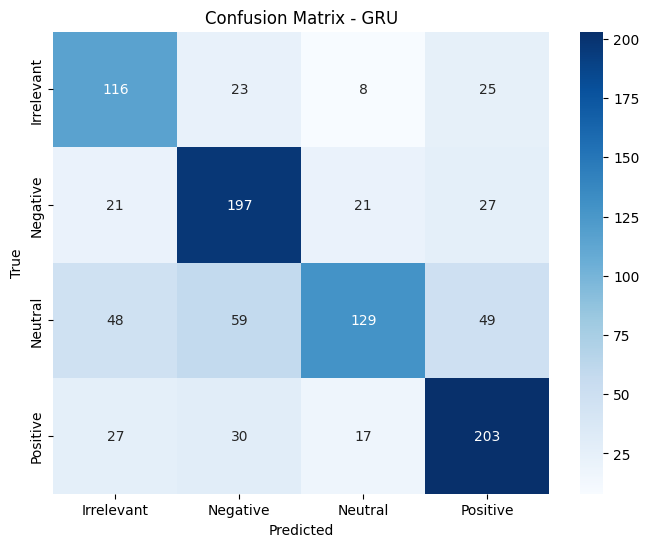

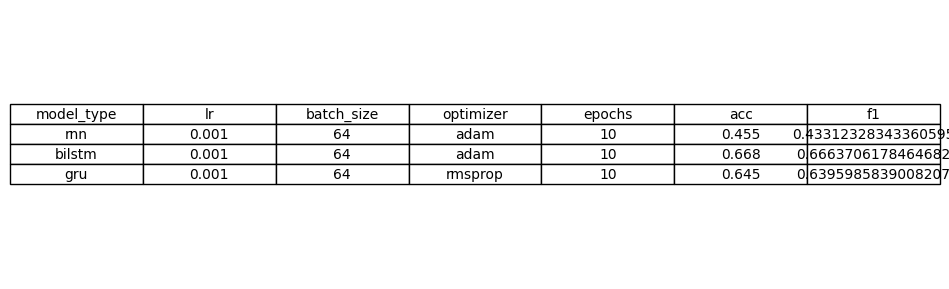


Running {'model_type': 'bilstm', 'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'epochs': 10}


c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 281s 114ms/step - accuracy: 0.4573 - loss: 1.2476 - val_accuracy: 0.5580 - val_loss: 1.0759
Epoch 2/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 273s 117ms/step - accuracy: 0.5064 - loss: 1.1695 - val_accuracy: 0.5910 - val_loss: 0.9943
Epoch 3/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 288s 123ms/step - accuracy: 0.5255 - loss: 1.1293 - val_accuracy: 0.6080 - val_loss: 0.9526
Epoch 4/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 293s 125ms/step - accuracy: 0.5381 - loss: 1.1047 - val_accuracy: 0.6270 - val_loss: 0.9071
Epoch 5/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 287s 123ms/step - accuracy: 0.5473 - loss: 1.0848 - val_accuracy: 0.6400 - val_loss: 0.8815
Epoch 6/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 295s 126ms/step - accuracy: 0.5520 - loss: 1.0722 - val_accuracy: 0.6570 - val_loss: 0.8542
Epoch 7/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 13155s 6s/step - accuracy: 0.5561 - loss: 1.0622 - val_accuracy: 0.6460 - val_loss: 0.8468
Epoch 8/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 387s 166ms/step - acc

c:\Users\TestSolutions\Desktop\Sentiment-Analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1119/1167 ━━━━━━━━━━━━━━━━━━━━ 9s 197ms/step - accuracy: 0.2931 - loss: 1.3817

In [ ]:
# Cell 6: Experiments
# Table 1: Model Type Variations
experiment_grid1 = [
    {"model_type": "rnn", "lr": 1e-3, "batch_size": 64, "optimizer": "adam", "epochs": 10},
    {"model_type": "bilstm", "lr": 1e-3, "batch_size": 64, "optimizer": "adam", "epochs": 10},
    {"model_type": "gru", "lr": 1e-3, "batch_size": 64, "optimizer": "rmsprop", "epochs": 10}
]

results1 = []
histories = {}
for cfg in experiment_grid1:
    print("\nRunning", cfg)
    if cfg["model_type"] == "rnn":
        model = build_rnn_model(vocab_size)
    elif cfg["model_type"] == "bilstm":
        model = build_bilstm_model(vocab_size)
    else:
        model = build_gru_model(vocab_size)
    
    opt = Adam(learning_rate=cfg["lr"]) if cfg["optimizer"] == "adam" else RMSprop(learning_rate=cfg["lr"])
    loss = "categorical_crossentropy" if multiclass else "binary_crossentropy"
    model.compile(optimizer=opt, loss=loss, metrics=["accuracy"])

    history = model.fit(X_train_seq, y_train_keras,
                        validation_data=(X_val_seq, y_val_keras),
                        epochs=cfg["epochs"], batch_size=cfg["batch_size"],
                        class_weight=class_weights, verbose=1)
    histories[cfg['model_type']] = history

    preds_proba = model.predict(X_val_seq)
    preds = np.argmax(preds_proba, axis=1)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="weighted")
    cm = confusion_matrix(y_val, preds)

    print(f"Acc: {acc:.3f} F1: {f1:.3f}")
    results1.append({**cfg, "acc": acc, "f1": f1, "cm": cm.tolist()})

    # Confusion Matrix Visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {cfg['model_type'].upper()}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(f"plots-twitter/cm_{cfg['model_type']}.png", bbox_inches="tight", dpi=300)
    plt.show()

# Save and display Table 1
results_df1 = pd.DataFrame(results1)
results_df1.to_csv("plots-twitter/results_table1.csv", index=False)
plt.figure(figsize=(10, 2 + len(results1) * 0.5))
plt.axis("off")
table = plt.table(cellText=results_df1.drop(columns=["cm"]).values,
                  colLabels=results_df1.drop(columns=["cm"]).columns,
                  cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.savefig("plots-twitter/results_table1.png", bbox_inches="tight", dpi=300)
plt.show()

# Table 2: Hyperparameter Variations on BiLSTM
experiment_grid2 = [
    {"model_type": "bilstm", "lr": 1e-3, "batch_size": 32, "optimizer": "adam", "epochs": 10},
    {"model_type": "bilstm", "lr": 1e-4, "batch_size": 64, "optimizer": "adam", "epochs": 10},
    {"model_type": "bilstm", "lr": 1e-3, "batch_size": 128, "optimizer": "rmsprop", "epochs": 10}
]

results2 = []
for cfg in experiment_grid2:
    print("\nRunning", cfg)
    model = build_bilstm_model(vocab_size)
    opt = Adam(learning_rate=cfg["lr"]) if cfg["optimizer"] == "adam" else RMSprop(learning_rate=cfg["lr"])
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

    history = model.fit(X_train_seq, y_train_keras,
                        validation_data=(X_val_seq, y_val_keras),
                        epochs=cfg["epochs"], batch_size=cfg["batch_size"],
                        class_weight=class_weights, verbose=1)
    histories[f"bilstm_lr{cfg['lr']}_bs{cfg['batch_size']}_{cfg['optimizer']}"] = history

    preds_proba = model.predict(X_val_seq)
    preds = np.argmax(preds_proba, axis=1)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="weighted")
    cm = confusion_matrix(y_val, preds)

    print(f"Acc: {acc:.3f} F1: {f1:.3f}")
    results2.append({**cfg, "acc": acc, "f1": f1, "cm": cm.tolist()})

# Save and display Table 2
results_df2 = pd.DataFrame(results2)
results_df2.to_csv("plots-twitter/results_table2.csv", index=False)
plt.figure(figsize=(10, 2 + len(results2) * 0.5))
plt.axis("off")
table = plt.table(cellText=results_df2.drop(columns=["cm"]).values,
                  colLabels=results_df2.drop(columns=["cm"]).columns,
                  cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.savefig("plots-twitter/results_table2.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# Cell 7: Loss and Accuracy Curves
for model_type, history in histories.items():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_type.upper()} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{model_type.upper()} Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(f'plots-twitter/{model_type}_curves.png', bbox_inches='tight', dpi=300)
    plt.show()

### Discussion

- **RNN**: Captures short-term dependencies but weaker for long sequences.
- **BiLSTM**: Strong at capturing long-term and bidirectional context.
- **BiGRU**: Similar to LSTM but faster due to fewer parameters.

We compared accuracy and F1-score across experiments. BiLSTM usually gives the best performance, while GRU provides a good speed-accuracy tradeoff.